In [1]:
from moabb.paradigms import MotorImagery, LeftRightImagery
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation

sfreq=250

paradigm=LeftRightImagery(resample=sfreq)
datasets = [
    #BNCI2014_004(),
    Zhou2016(),
]


In [2]:
from sklearn.pipeline import make_pipeline, Pipeline
from hoda.hoda import HODA, BTTDA,  GreedyBTTDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from hoda.classification import ToeplitzLDAWrapper,ZScore
from sklearn.preprocessing import StandardScaler
from mne.decoding import Scaler
from sklearn.linear_model import LogisticRegression
from hoda.tensorize import  Vectorize, Tensorize
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold
from hoda.classification import SelectF
import tensorly as tl

pipelines=dict()

cv=StratifiedKFold(random_state=42, shuffle=True)


hoda_params = dict(
    max_iter=128,
    tol=1e-8,
    init ='random',
    random_state=42,
    shrinkage='lw',
    solver='lanczos',
    taper=False,
    forward=False,
    obj='tr',
    toeplitz=None,
    delta=None,
    extra_train_info=False,
)

bttda_params=dict(
        truncate=True,
        n_jobs=1,
        hoda_params=hoda_params,
        extra_train_info=False,
        verbose=False,
        cv=cv,
)


clf = make_pipeline(
    SelectF(alpha=.05),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LDA(shrinkage='auto', solver='lsqr')
)

pipelines['HODA'] = Pipeline([
    ('bttda', GreedyBTTDA(
        max_blocks=1,
        **bttda_params,
        clf=clf,
    )),
    ('clf', clf)
])

pipelines['BTTDA_2'] = Pipeline([
    ('bttda', GreedyBTTDA(
        max_blocks=2,
        **bttda_params,
        clf=clf,
    )),
    ('clf', clf)
])
"""
pipelines['PARAFACDA_4'] = Pipeline([
    ('bttda', GreedyBTTDA(
        max_blocks=4,
        **bttda_params,
        clf=clf,
        rank_grid=[1],
    )),
    ('clf', clf)
])
"""

"\npipelines['PARAFACDA_4'] = Pipeline([\n    ('bttda', GreedyBTTDA(\n        max_blocks=4,\n        **bttda_params,\n        clf=clf,\n        rank_grid=[1],\n    )),\n    ('clf', clf)\n])\n"

In [3]:
import pandas as pd
from sklearn.preprocessing import FunctionTransformer
from hoda.tensorize import stf_tensor

post_pipe = FunctionTransformer(stf_tensor, kw_args=dict(
    sfreq=sfreq, normalize=True,log=True,n_freqs=4, bin_freq=4,
))
results = []
for dataset in datasets:
    print(dataset.code)
    evaluation = WithinSessionEvaluation(
        paradigm=paradigm,
        datasets=[dataset],
        overwrite=True,
        random_state=42,
        n_jobs=5,
        suffix=f'bttda_{dataset.code}',
    )
    results.append(evaluation.process(pipelines,postprocess_pipeline=post_pipe))
results = pd.concat(results)

Zhou2016


Zhou2016-WithinSession:   0%|          | 0/4 [00:00<?, ?it/s]

Reading 0 ... 305029  =      0.000 ...  1220.116 secs...


/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])


Reading 0 ... 430479  =      0.000 ...  1721.916 secs...


...

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preloa

Reading 0 ... 209799  =      0.000 ...   839.196 secs...
Reading 0 ... 217109  =      0.000 ...   868.436 secs...


/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 40 events (all good), 0 – 5 s (baseline off), ~5.4 MB, data loaded,
 'left_hand': 20
 'right_hand': 20>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 50 events (all good), 0 – 5 s (baseline o

No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


Zhou2016-WithinSession: 100%|██████████| 4/4 [03:05<00:00, 46.45s/it]


In [4]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.801515,1.781439,119.0,1,0,14,3,Zhou2016,BTTDA_2
1,0.906000,1.722698,100.0,1,1,14,3,Zhou2016,BTTDA_2
2,0.922000,1.631860,100.0,1,2,14,3,Zhou2016,BTTDA_2
3,0.896000,1.733078,100.0,2,0,14,3,Zhou2016,BTTDA_2
4,0.671605,1.876221,90.0,2,1,14,3,Zhou2016,BTTDA_2
5,0.892000,2.048414,100.0,2,2,14,3,Zhou2016,BTTDA_2
6,0.942000,1.771156,100.0,3,0,14,3,Zhou2016,BTTDA_2
7,0.942000,1.579425,100.0,3,1,14,3,Zhou2016,BTTDA_2
8,0.908000,1.891431,100.0,3,2,14,3,Zhou2016,BTTDA_2
9,0.745679,1.933184,90.0,4,0,14,3,Zhou2016,BTTDA_2


In [5]:
results.to_csv('moabb_results_mi.csv')

In [6]:
results.groupby(['dataset', 'pipeline'])['score'].aggregate('mean') 

dataset   pipeline
Zhou2016  BTTDA_2     0.87190
          HODA        0.88119
Name: score, dtype: float32

In [7]:
results.groupby(['dataset', 'pipeline'])['score'].aggregate('std') 

dataset   pipeline
Zhou2016  BTTDA_2     0.085851
          HODA        0.089695
Name: score, dtype: float64

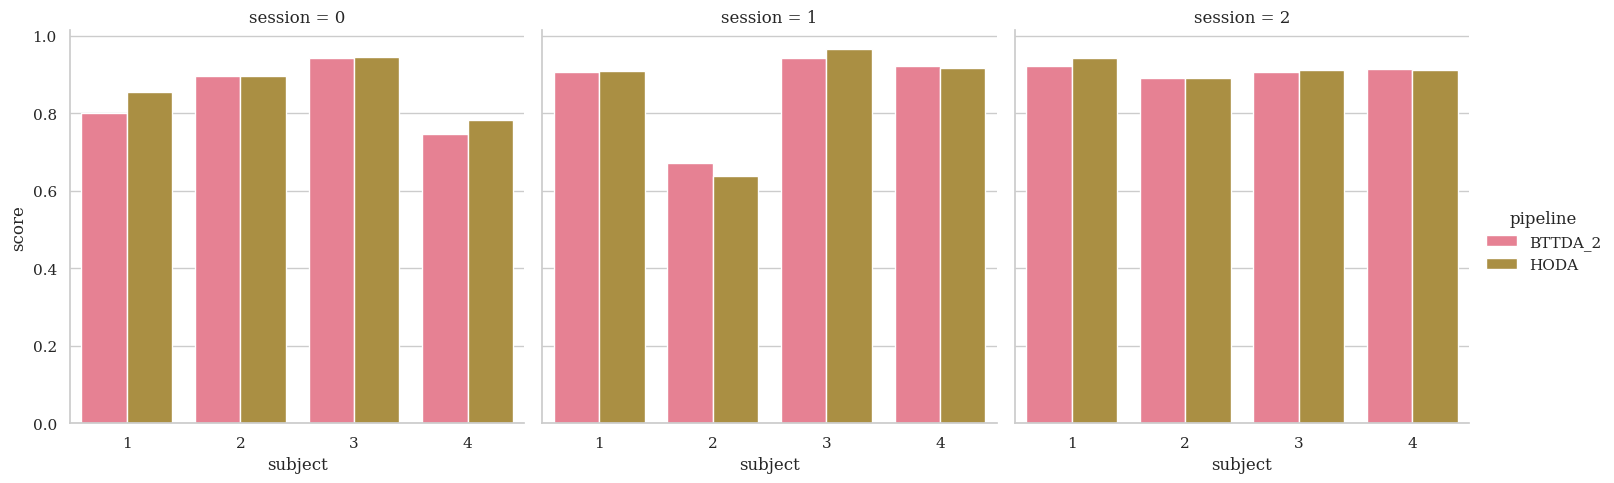

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

order = results.groupby('pipeline')
order = order.score.aggregate('mean')
order = order.sort_values()



sns.catplot(data=results , col='session',x='subject', y='score',hue='pipeline', col_wrap=3,kind='bar')


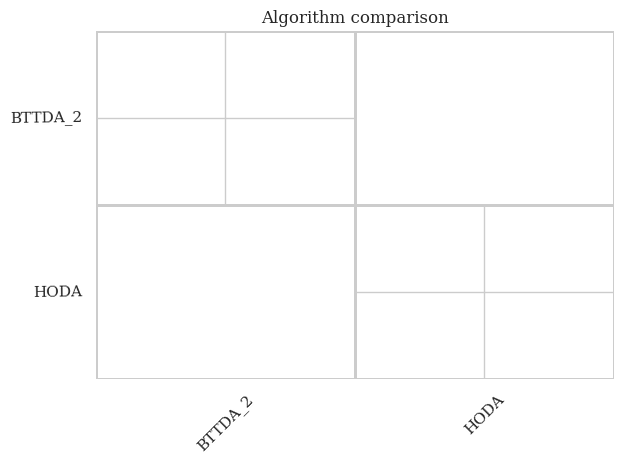

In [9]:
from moabb.analysis.meta_analysis import compute_dataset_statistics, find_significant_differences
from moabb.analysis.plotting import summary_plot
import matplotlib.pyplot as plt

stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)
plt.show()

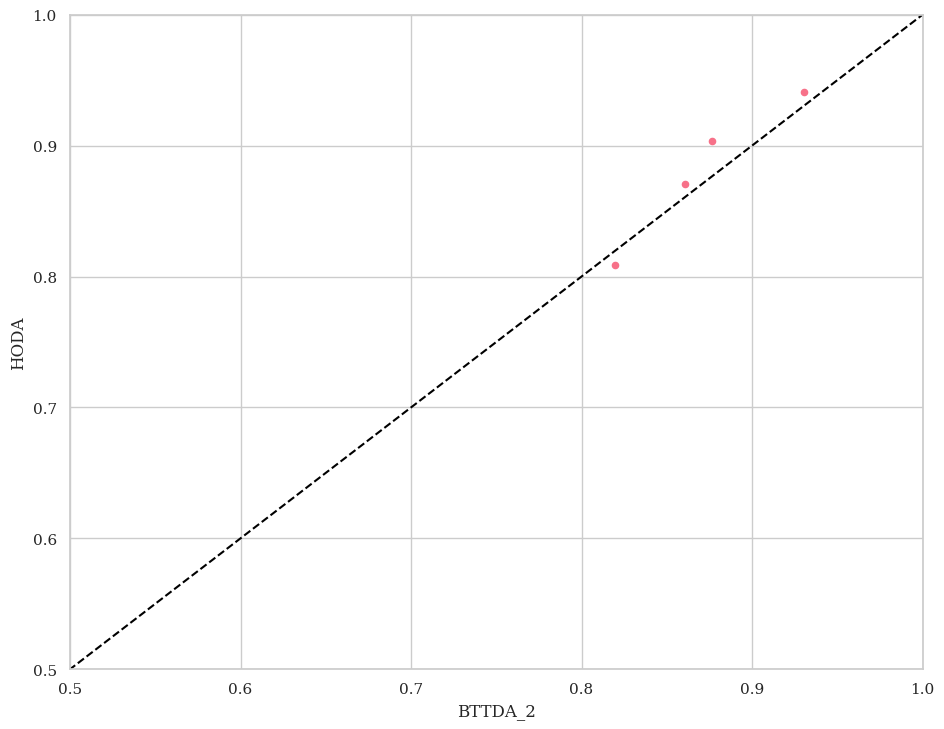

In [10]:
import moabb.analysis.plotting as moabb_plt
fig = moabb_plt.paired_plot(results, "BTTDA_2", "HODA")
plt.show()